## Setup & Data Loading

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sns.set_theme(style="white", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.family": "sans-serif",
})

BLUE = "#4361EE"
RED = "#E63946"
GREEN = "#06D6A0"
YELLOW = "#FFD166"
ORANGE = "#F77F00"
GREY = "#ADB5BD"
DARK = "#212529"

con = duckdb.connect()
for table in ["users", "tracks", "artists", "sessions", "events"]:
    con.execute(f"""
        CREATE TABLE {table} AS
        SELECT * FROM read_csv_auto('../daily_mix_data/{table}.csv')
    """)
    n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"  {table}: {n:,} rows")

print("\nAll tables loaded.")

  users: 12,000 rows
  tracks: 2,441 rows
  artists: 500 rows
  sessions: 97,945 rows
  events: 747,848 rows

All tables loaded.


## Experiment Overview & Balance Check
Before analysing results, we verify the randomisation produced balanced groups across key dimensions. Any significant imbalance would threaten the validity of the experiment.

In [2]:
balance = con.execute("""
    SELECT
        experiment_variant,
        COUNT(*) AS users,
        ROUND(100.0 * COUNT(CASE WHEN platform = 'iOS' THEN 1 END) / COUNT(*), 1) AS ios_pct,
        ROUND(100.0 * COUNT(CASE WHEN platform = 'Android' THEN 1 END) / COUNT(*), 1) AS android_pct,
        ROUND(100.0 * COUNT(CASE WHEN platform = 'Web' THEN 1 END) / COUNT(*), 1) AS web_pct,
        ROUND(100.0 * COUNT(CASE WHEN initial_plan = 'free' THEN 1 END) / COUNT(*), 1) AS free_pct,
        ROUND(100.0 * COUNT(CASE WHEN country = 'US' THEN 1 END) / COUNT(*), 1) AS us_pct,
        ROUND(100.0 * COUNT(CASE WHEN country = 'UK' THEN 1 END) / COUNT(*), 1) AS uk_pct,
        ROUND(100.0 * COUNT(CASE WHEN country = 'DE' THEN 1 END) / COUNT(*), 1) AS de_pct,
        ROUND(100.0 * COUNT(CASE WHEN country = 'IN' THEN 1 END) / COUNT(*), 1) AS in_pct,
        ROUND(100.0 * COUNT(CASE WHEN country = 'BR' THEN 1 END) / COUNT(*), 1) AS br_pct
    FROM users
    GROUP BY experiment_variant
    ORDER BY experiment_variant
""").fetchdf()

print(balance.to_string(index=False))

# Chi-squared test for platform balance
platform_ct = con.execute("""
    SELECT experiment_variant, platform, COUNT(*) AS n
    FROM users GROUP BY experiment_variant, platform
""").fetchdf()
ct = platform_ct.pivot(index="experiment_variant", columns="platform", values="n").fillna(0)
chi2, p_val, _, _ = stats.chi2_contingency(ct)
print(f"\nPlatform balance -- Chi-squared: {chi2:.2f}, p-value: {p_val:.4f}")
print("Balanced" if p_val > 0.05 else "Imbalanced -- investigate")

experiment_variant  users  ios_pct  android_pct  web_pct  free_pct  us_pct  uk_pct  de_pct  in_pct  br_pct
           control   6065     45.0         41.3     13.7      88.1    35.4    19.6    14.7    18.9    11.5
         daily_mix   5935     45.0         41.8     13.2      87.6    34.1    20.5    14.9    18.2    12.2

Platform balance -- Chi-squared: 0.71, p-value: 0.6995
Balanced


## Primary Metric: D30 Retention
The headline question — does Daily Mix improve 30-day retention for new users? We report proportions with a two-proportion z-test and 95% confidence intervals.

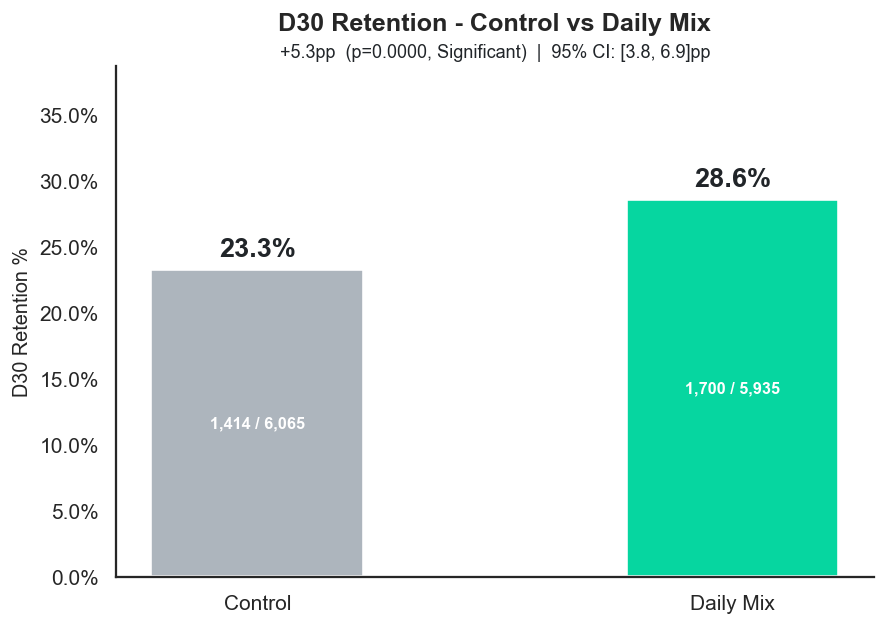

Control:   23.31%  (1,414 / 6,065)
Treatment: 28.64%  (1,700 / 5,935)
Absolute lift: +5.33 pp
Relative lift: +22.9%
Z-stat: 6.659, p-value: 0.0000
95% CI for difference: [3.76, 6.90] pp


In [3]:
retention = con.execute("""
    WITH d30 AS (
        SELECT DISTINCT e.user_id
        FROM events e JOIN users u ON e.user_id = u.user_id
        WHERE CAST(e.event_time AS DATE) = CAST(u.signup_date AS DATE) + 30
          AND e.event_type IN ('play', 'app_open', 'daily_mix_play')
    )
    SELECT
        u.experiment_variant,
        COUNT(DISTINCT u.user_id) AS cohort,
        COUNT(DISTINCT d30.user_id) AS retained
    FROM users u
    LEFT JOIN d30 ON u.user_id = d30.user_id
    GROUP BY u.experiment_variant
    ORDER BY u.experiment_variant
""").fetchdf()

ctrl = retention[retention["experiment_variant"] == "control"].iloc[0]
treat = retention[retention["experiment_variant"] == "daily_mix"].iloc[0]

ctrl_rate = ctrl["retained"] / ctrl["cohort"]
treat_rate = treat["retained"] / treat["cohort"]
lift_pp = (treat_rate - ctrl_rate) * 100
lift_rel = (treat_rate - ctrl_rate) / ctrl_rate * 100

# Two-proportion z-test
count = np.array([treat["retained"], ctrl["retained"]])
nobs = np.array([treat["cohort"], ctrl["cohort"]])
z_stat, p_value = proportions_ztest(count, nobs)

# 95% confidence interval for the difference
se = np.sqrt(ctrl_rate * (1 - ctrl_rate) / ctrl["cohort"]
             + treat_rate * (1 - treat_rate) / treat["cohort"])
ci_low = (treat_rate - ctrl_rate) - 1.96 * se
ci_high = (treat_rate - ctrl_rate) + 1.96 * se

# Chart
fig, ax = plt.subplots(figsize=(7, 5))
variants = ["Control", "Daily Mix"]
rates = [ctrl_rate * 100, treat_rate * 100]
colors = [GREY, GREEN]

bars = ax.bar(variants, rates, color=colors, width=0.45, edgecolor="white", linewidth=2)

ax.set_ylim(0, max(rates) * 1.35)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("D30 Retention - Control vs Daily Mix", fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("D30 Retention %", fontsize=11)

for bar, rate, n_retained, n_total in zip(bars, rates, [ctrl["retained"], treat["retained"]],
                                           [ctrl["cohort"], treat["cohort"]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(rates) * 0.02,
            f"{rate:.1f}%", ha="center", va="bottom", fontsize=15, fontweight="bold", color=DARK)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.5,
            f"{int(n_retained):,} / {int(n_total):,}", ha="center", va="center",
            fontsize=9, color="white", fontweight="bold")

sig_label = "Significant" if p_value < 0.05 else "Not significant"
ax.text(0.5, 1.01,
        f"+{lift_pp:.1f}pp  (p={p_value:.4f}, {sig_label})  |  95% CI: [{ci_low*100:.1f}, {ci_high*100:.1f}]pp",
        transform=ax.transAxes, fontsize=10, color=DARK, ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(f"Control:   {ctrl_rate*100:.2f}%  ({int(ctrl['retained']):,} / {int(ctrl['cohort']):,})")
print(f"Treatment: {treat_rate*100:.2f}%  ({int(treat['retained']):,} / {int(treat['cohort']):,})")
print(f"Absolute lift: +{lift_pp:.2f} pp")
print(f"Relative lift: +{lift_rel:.1f}%")
print(f"Z-stat: {z_stat:.3f}, p-value: {p_value:.4f}")
print(f"95% CI for difference: [{ci_low*100:.2f}, {ci_high*100:.2f}] pp")

## D7 Retention
Earlier retention signal — do we see the effect at day 7 as well?

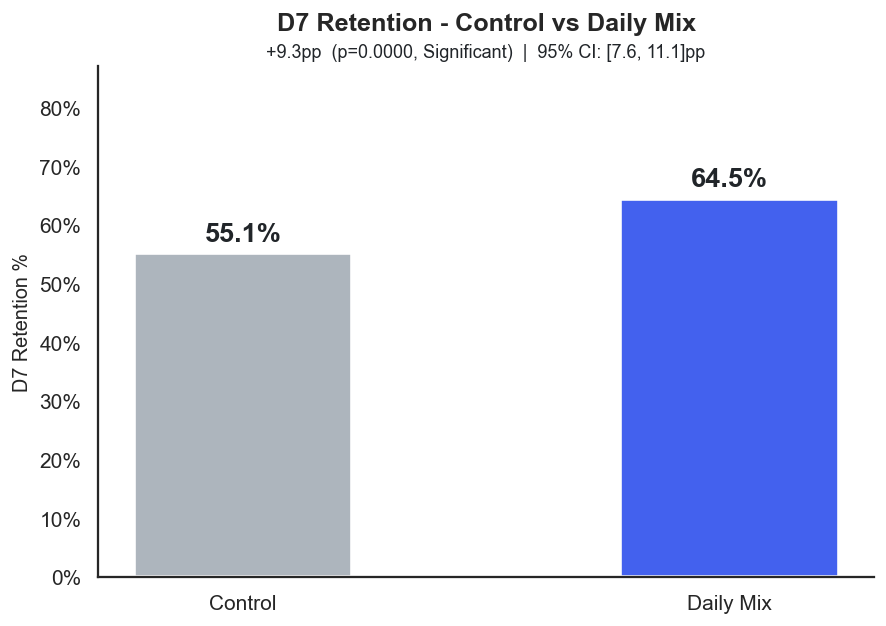

In [4]:
ret_d7 = con.execute("""
    WITH d7 AS (
        SELECT DISTINCT e.user_id
        FROM events e JOIN users u ON e.user_id = u.user_id
        WHERE CAST(e.event_time AS DATE) = CAST(u.signup_date AS DATE) + 7
          AND e.event_type IN ('play', 'app_open', 'daily_mix_play')
    )
    SELECT
        u.experiment_variant,
        COUNT(DISTINCT u.user_id) AS cohort,
        COUNT(DISTINCT d7.user_id) AS retained
    FROM users u
    LEFT JOIN d7 ON u.user_id = d7.user_id
    GROUP BY u.experiment_variant
    ORDER BY u.experiment_variant
""").fetchdf()

ctrl7 = ret_d7[ret_d7["experiment_variant"] == "control"].iloc[0]
treat7 = ret_d7[ret_d7["experiment_variant"] == "daily_mix"].iloc[0]

ctrl7_rate = ctrl7["retained"] / ctrl7["cohort"]
treat7_rate = treat7["retained"] / treat7["cohort"]

count7 = np.array([treat7["retained"], ctrl7["retained"]])
nobs7 = np.array([treat7["cohort"], ctrl7["cohort"]])
z7, p7 = proportions_ztest(count7, nobs7)

se7 = np.sqrt(ctrl7_rate * (1 - ctrl7_rate) / ctrl7["cohort"]
              + treat7_rate * (1 - treat7_rate) / treat7["cohort"])
ci7_low = (treat7_rate - ctrl7_rate) - 1.96 * se7
ci7_high = (treat7_rate - ctrl7_rate) + 1.96 * se7

fig, ax = plt.subplots(figsize=(7, 5))
rates7 = [ctrl7_rate * 100, treat7_rate * 100]
bars = ax.bar(["Control", "Daily Mix"], rates7, color=[GREY, BLUE],
              width=0.45, edgecolor="white", linewidth=2)

ax.set_ylim(0, max(rates7) * 1.35)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("D7 Retention - Control vs Daily Mix", fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("D7 Retention %", fontsize=11)

for bar, rate in zip(bars, rates7):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(rates7) * 0.02,
            f"{rate:.1f}%", ha="center", va="bottom", fontsize=15, fontweight="bold", color=DARK)

sig7 = "Significant" if p7 < 0.05 else "Not significant"
lift7 = (treat7_rate - ctrl7_rate) * 100
ax.text(0.5, 1.01,
        f"+{lift7:.1f}pp  (p={p7:.4f}, {sig7})  |  95% CI: [{ci7_low*100:.1f}, {ci7_high*100:.1f}]pp",
        transform=ax.transAxes, fontsize=10, color=DARK, ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Weekly Listening Minutes
Engagement metric — does Daily Mix drive more listening? We report median (primary), mean, and Winsorized mean (capped at p95) to handle power-user skew.

experiment_variant  week_num  users  mean_min  median_min  winsorized_mean
           control       1.0   6045      34.2        28.8             32.3
           control       2.0   4790      16.6        12.6             16.5
           control       3.0   1952      12.5         9.9             12.4
           control       4.0   1632      11.9         9.7             11.9
         daily_mix       1.0   5916      38.8        34.0             36.0
         daily_mix       2.0   4963      18.1        13.4             17.9
         daily_mix       3.0   2076      13.4        10.2             13.3
         daily_mix       4.0   1718      12.9        10.5             12.9


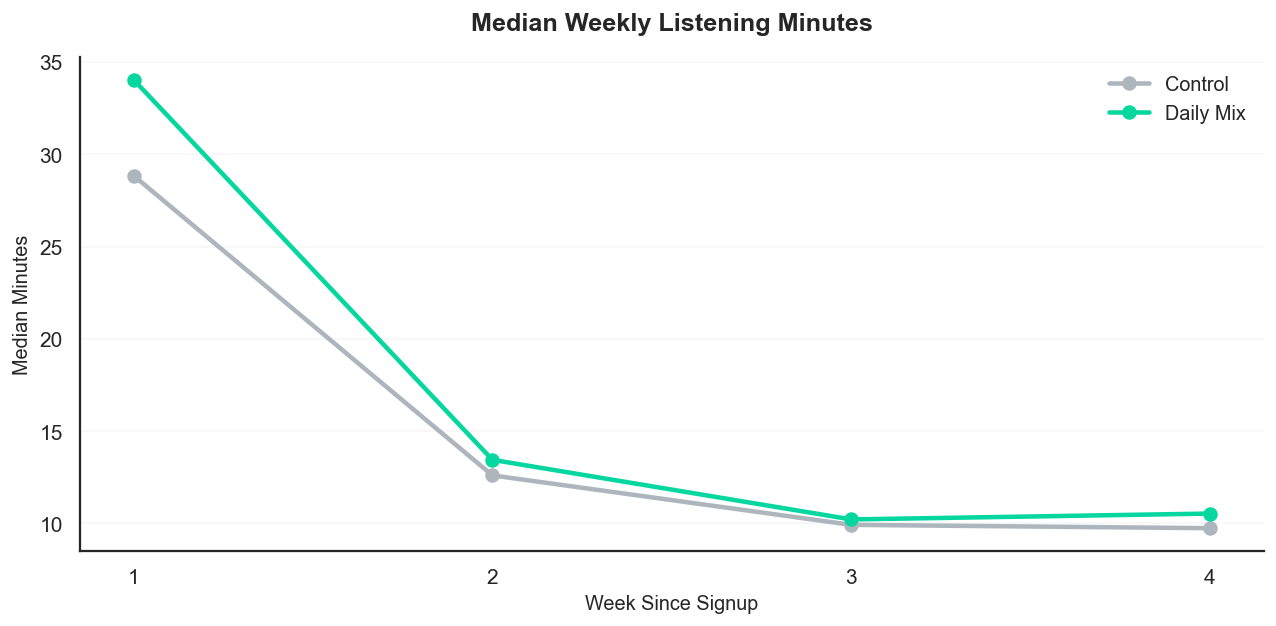


Total first-4-weeks listening minutes per user:
  Control  -- median: 45.6, mean: 54.4
  Treatment -- median: 52.4, mean: 62.2
  Median lift: +14.7%
  Mann-Whitney U: 19,922,513, p-value: 0.0000


In [5]:
weekly = con.execute("""
    SELECT
        u.user_id,
        u.experiment_variant,
        FLOOR((CAST(s.session_start AS DATE) - CAST(u.signup_date AS DATE)) / 7) + 1 AS week_num,
        SUM(s.total_play_ms) / 60000.0 AS listening_min
    FROM sessions s
    JOIN users u ON s.user_id = u.user_id
    WHERE CAST(s.session_start AS DATE) - CAST(u.signup_date AS DATE) BETWEEN 0 AND 27
    GROUP BY u.user_id, u.experiment_variant, week_num
""").fetchdf()

# Winsorize at p95
p95 = weekly["listening_min"].quantile(0.95)
weekly["winsorized_min"] = weekly["listening_min"].clip(upper=p95)

summary = weekly.groupby(["experiment_variant", "week_num"]).agg(
    users=("user_id", "nunique"),
    mean_min=("listening_min", "mean"),
    median_min=("listening_min", "median"),
    winsorized_mean=("winsorized_min", "mean"),
).reset_index()

print(summary.round(1).to_string(index=False))

# Chart: median listening per week by variant
fig, ax = plt.subplots(figsize=(10, 5))

for variant, color, label in [("control", GREY, "Control"), ("daily_mix", GREEN, "Daily Mix")]:
    data = summary[summary["experiment_variant"] == variant].sort_values("week_num")
    ax.plot(data["week_num"], data["median_min"], marker="o", color=color,
            linewidth=2.5, markersize=7, label=label)

ax.set_title("Median Weekly Listening Minutes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Week Since Signup", fontsize=11)
ax.set_ylabel("Median Minutes", fontsize=11)
ax.set_xticks(sorted(summary["week_num"].unique()))
ax.legend(fontsize=11, frameon=False)
ax.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.show()

# Statistical test on total D0-D27 listening per user
total_per_user = weekly.groupby(["user_id", "experiment_variant"])["listening_min"].sum().reset_index()
ctrl_min = total_per_user[total_per_user["experiment_variant"] == "control"]["listening_min"]
treat_min = total_per_user[total_per_user["experiment_variant"] == "daily_mix"]["listening_min"]

# Mann-Whitney U (non-parametric, better for skewed data)
# Note: this is a per-protocol comparison -- users with zero sessions in the first
# 4 weeks are excluded because they have no session rows. Both arms lose ~5% of
# users equally, so ITT and per-protocol results are directionally the same.
u_stat, u_pval = stats.mannwhitneyu(treat_min, ctrl_min, alternative="greater")
lift_median = (treat_min.median() - ctrl_min.median()) / ctrl_min.median() * 100

print(f"\nTotal first-4-weeks listening minutes per user:")
print(f"  Control  -- median: {ctrl_min.median():.1f}, mean: {ctrl_min.mean():.1f}")
print(f"  Treatment -- median: {treat_min.median():.1f}, mean: {treat_min.mean():.1f}")
print(f"  Median lift: +{lift_median:.1f}%")
print(f"  Mann-Whitney U: {u_stat:,.0f}, p-value: {u_pval:.4f}")

## Daily Mix Funnel
How do treatment users interact with the Daily Mix tile? Tracking the funnel from impression through to repeat engagement and saves.

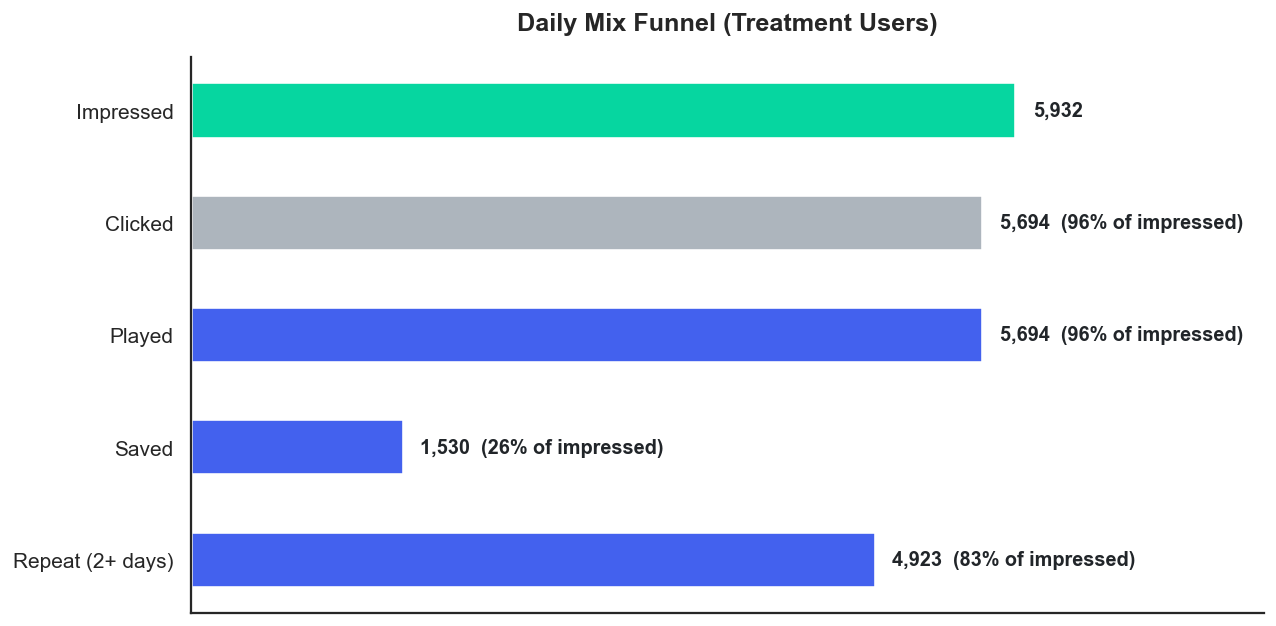

In [6]:
funnel = con.execute("""
    WITH dm_users AS (
        SELECT user_id FROM users WHERE experiment_variant = 'daily_mix'
    )
    SELECT
        COUNT(DISTINCT CASE WHEN e.event_type = 'daily_mix_impression' THEN e.user_id END) AS impressed,
        COUNT(DISTINCT CASE WHEN e.event_type = 'daily_mix_click' THEN e.user_id END) AS clicked,
        COUNT(DISTINCT CASE WHEN e.event_type = 'daily_mix_play' THEN e.user_id END) AS played,
        COUNT(DISTINCT CASE WHEN e.event_type = 'daily_mix_save' THEN e.user_id END) AS saved
    FROM events e
    JOIN dm_users d ON e.user_id = d.user_id
""").fetchdf()

# Repeat players: played on 2+ distinct days
repeat = con.execute("""
    SELECT COUNT(DISTINCT user_id) AS repeat_players
    FROM (
        SELECT user_id, COUNT(DISTINCT CAST(event_time AS DATE)) AS play_days
        FROM events
        WHERE event_type = 'daily_mix_play'
        GROUP BY user_id
        HAVING play_days >= 2
    )
""").fetchdf()

stages = ["Impressed", "Clicked", "Played", "Saved", "Repeat (2+ days)"]
values = [
    int(funnel["impressed"].iloc[0]),
    int(funnel["clicked"].iloc[0]),
    int(funnel["played"].iloc[0]),
    int(funnel["saved"].iloc[0]),
    int(repeat["repeat_players"].iloc[0]),
]

# Each stage's conversion is relative to the top of funnel (Impressed)
top = values[0]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(stages[::-1], values[::-1], color=[GREEN, GREY, BLUE, BLUE, BLUE][::-1],
               height=0.5, edgecolor="white", linewidth=2)

ax.set_xlim(0, max(values) * 1.3)
ax.xaxis.set_visible(False)
ax.set_title("Daily Mix Funnel (Treatment Users)", fontsize=14, fontweight="bold", pad=15)

for bar, val, stage_idx in zip(bars, values[::-1], range(len(values))):
    orig_idx = len(values) - 1 - stage_idx
    if orig_idx == 0:
        label = f"{val:,}"
    else:
        conv = val / top * 100 if top > 0 else 0
        label = f"{val:,}  ({conv:.0f}% of impressed)"
    ax.text(bar.get_width() + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=11, fontweight="bold", color=DARK)

plt.tight_layout()
plt.show()

## Guardrail: Search & Discover Usage
Does Daily Mix cannibalise exploration? If search usage drops significantly (threshold: >5%), the feature may be discouraging organic discovery.

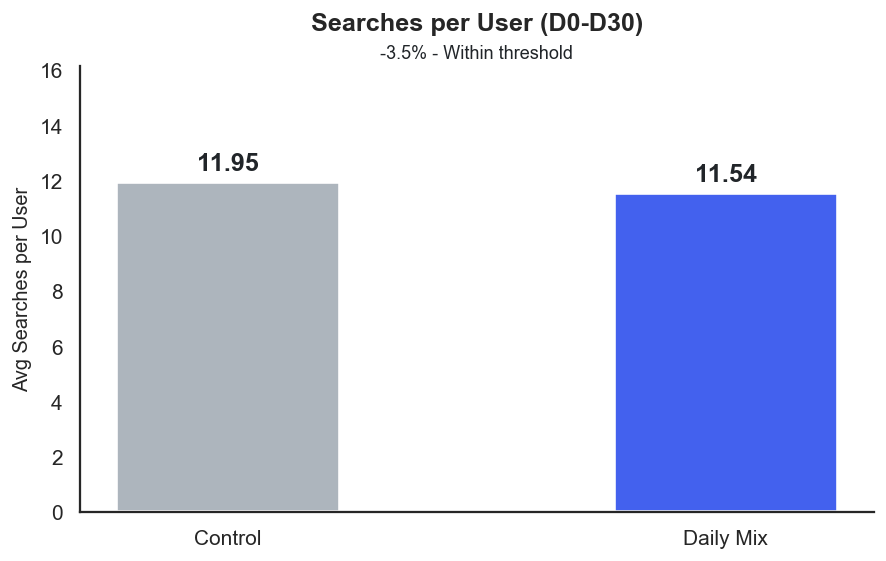

In [7]:
search_usage = con.execute("""
    SELECT
        u.experiment_variant,
        COUNT(CASE WHEN e.event_type = 'search' THEN 1 END) AS search_events,
        COUNT(DISTINCT CASE WHEN e.event_type = 'search' THEN e.user_id END) AS searchers,
        COUNT(DISTINCT u.user_id) AS total_users
    FROM events e
    JOIN users u ON e.user_id = u.user_id
    WHERE CAST(e.event_time AS DATE) < CAST(u.signup_date AS DATE) + 31
    GROUP BY u.experiment_variant
    ORDER BY u.experiment_variant
""").fetchdf()

search_usage["searches_per_user"] = search_usage["search_events"] / search_usage["total_users"]
search_usage["searcher_pct"] = search_usage["searchers"] / search_usage["total_users"] * 100

ctrl_spu = search_usage.loc[search_usage["experiment_variant"] == "control", "searches_per_user"].values[0]
treat_spu = search_usage.loc[search_usage["experiment_variant"] == "daily_mix", "searches_per_user"].values[0]
search_change = (treat_spu - ctrl_spu) / ctrl_spu * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
variants = ["Control", "Daily Mix"]
vals = [ctrl_spu, treat_spu]
colors = [GREY, BLUE]

bars = ax.bar(variants, vals, color=colors, width=0.45, edgecolor="white", linewidth=2)
ax.set_ylim(0, max(vals) * 1.35)
ax.set_title("Searches per User (D0-D30)", fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Avg Searches per User", fontsize=11)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(vals) * 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

threshold_ok = abs(search_change) <= 5
status = f"{search_change:+.1f}% - {'Within threshold' if threshold_ok else 'Exceeds threshold'}"
ax.text(0.5, 1.01, status, transform=ax.transAxes, fontsize=10, color=DARK,
        ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Guardrail: Artist Diversity
Does Daily Mix narrow the range of artists users hear? We measure **unique artists per 100 plays** — this normalizes for the fact that treatment users listen more overall. Without this normalization, raw artist counts would be inflated by higher engagement. Threshold: diversity should not drop more than 10% vs control.

experiment_variant  mean  median   std  count
           control 66.81   63.64 28.56   6060
         daily_mix 53.55   50.00 21.66   5928


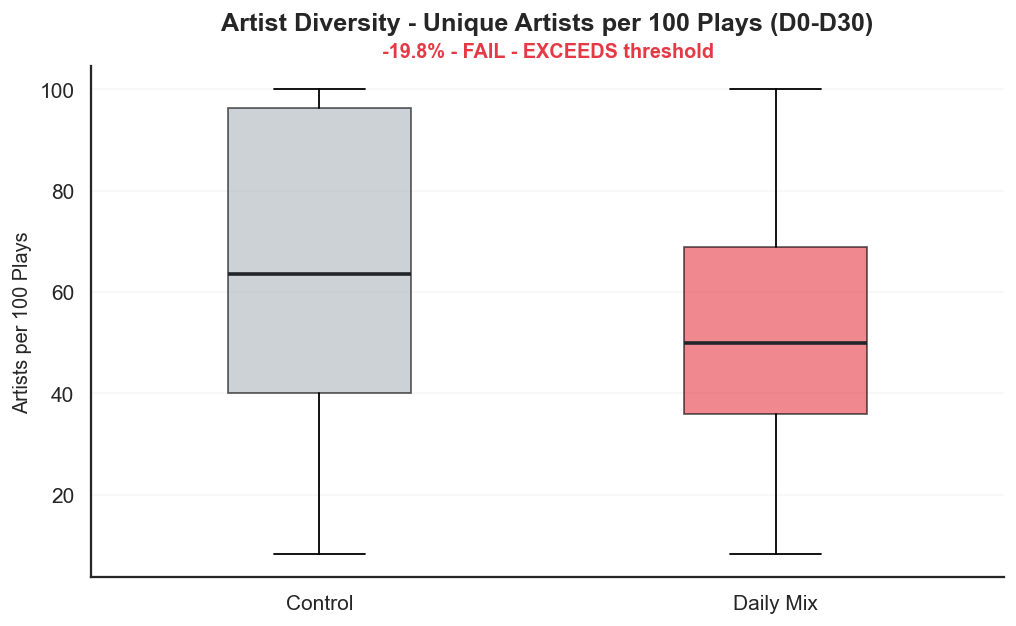


Diversity change: -19.8%
Mann-Whitney U: 22,682,488, p-value: 0.0000
Threshold (+/-10%): FAIL


In [8]:
diversity = con.execute("""
    SELECT
        u.experiment_variant,
        u.user_id,
        COUNT(DISTINCT t.artist_id) AS unique_artists,
        COUNT(*) AS total_plays,
        COUNT(DISTINCT t.artist_id) * 100.0 / COUNT(*) AS artists_per_100_plays
    FROM events e
    JOIN users u ON e.user_id = u.user_id
    JOIN tracks t ON e.track_id = t.track_id
    WHERE e.event_type IN ('play', 'daily_mix_play')
      AND CAST(e.event_time AS DATE) < CAST(u.signup_date AS DATE) + 31
    GROUP BY u.experiment_variant, u.user_id
""").fetchdf()

div_summary = diversity.groupby("experiment_variant")["artists_per_100_plays"].agg(
    ["mean", "median", "std", "count"]
).reset_index()
print(div_summary.round(2).to_string(index=False))

ctrl_div = diversity[diversity["experiment_variant"] == "control"]["artists_per_100_plays"]
treat_div = diversity[diversity["experiment_variant"] == "daily_mix"]["artists_per_100_plays"]

div_change = (treat_div.mean() - ctrl_div.mean()) / ctrl_div.mean() * 100
u_div, p_div = stats.mannwhitneyu(ctrl_div, treat_div, alternative="two-sided")

fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(
    [ctrl_div, treat_div],
    tick_labels=["Control", "Daily Mix"],
    widths=0.4,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color=DARK, linewidth=2),
)
bp["boxes"][0].set_facecolor(GREY)
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor(RED)
bp["boxes"][1].set_alpha(0.6)

ax.set_title("Artist Diversity - Unique Artists per 100 Plays (D0-D30)",
             fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Artists per 100 Plays", fontsize=11)
ax.grid(axis="y", alpha=0.15)

threshold_ok = abs(div_change) <= 10
status = f"{div_change:+.1f}% - {'PASS - Within threshold' if threshold_ok else 'FAIL - EXCEEDS threshold'}"
status_color = GREEN if threshold_ok else RED
ax.text(0.5, 1.01, status, transform=ax.transAxes, fontsize=11,
        fontweight="bold", color=status_color, ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(f"\nDiversity change: {div_change:+.1f}%")
print(f"Mann-Whitney U: {u_div:,.0f}, p-value: {p_div:.4f}")
print(f"Threshold (+/-10%): {'PASS' if threshold_ok else 'FAIL'}")

## Cannibalization Check
Is Daily Mix creating *net new* listening, or just stealing minutes from other surfaces? We compare total listening and per-source breakdown across variants.

> **Note:** Minutes here use full track duration (from the tracks table) rather than actual play time, because source attribution is only available on events. Since both arms use the same metric, the relative comparison is valid.

experiment_variant  control  daily_mix  change_pct
surface                                           
Daily Mix               0.0       36.6         NaN
Search                 29.6       30.6         3.5
Home (other)           45.5       22.6       -50.2


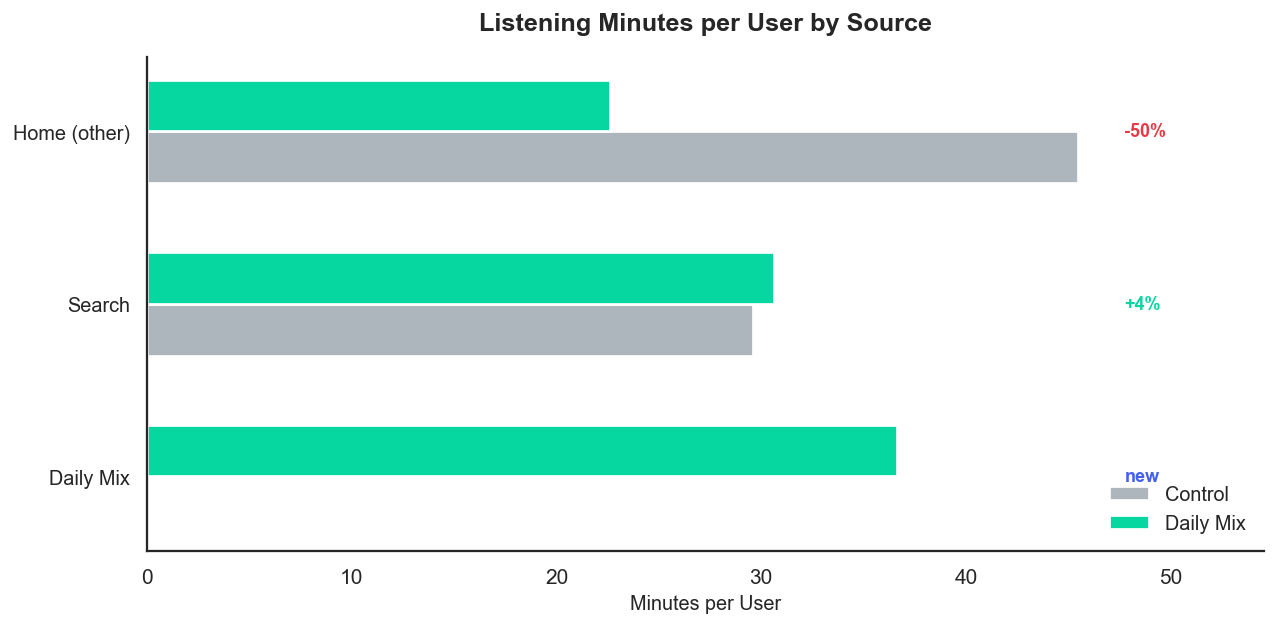


Total listening minutes -- change: +11.2%


In [9]:
cannibal = con.execute("""
    SELECT
        u.experiment_variant,
        CASE
            WHEN e.source = 'daily_mix' THEN 'Daily Mix'
            WHEN e.source = 'search'    THEN 'Search'
            WHEN e.source = 'home'      THEN 'Home (other)'
            WHEN e.source = 'playlist'  THEN 'Editorial Playlist'
            ELSE 'Other'
        END AS surface,
        SUM(t.duration_ms) / 60000.0 AS total_min,
        COUNT(DISTINCT e.user_id) AS users
    FROM events e
    JOIN users u ON e.user_id = u.user_id
    JOIN tracks t ON e.track_id = t.track_id
    WHERE e.event_type IN ('play', 'daily_mix_play')
      AND CAST(e.event_time AS DATE) < CAST(u.signup_date AS DATE) + 31
    GROUP BY u.experiment_variant, surface
""").fetchdf()

cannibal["min_per_user"] = cannibal["total_min"] / cannibal["users"]

# Pivot for side-by-side comparison
pivot = cannibal.pivot_table(index="surface", columns="experiment_variant",
                              values="min_per_user", aggfunc="sum").fillna(0)
pivot = pivot.reindex(columns=["control", "daily_mix"])
pivot["change_pct"] = np.where(
    pivot["control"] > 0,
    ((pivot["daily_mix"] - pivot["control"]) / pivot["control"] * 100).round(1),
    np.nan  # Daily Mix surface has no control baseline -- show as "new"
)
pivot = pivot.sort_values("control", ascending=True)

print(pivot.round(1).to_string())

# Chart
fig, ax = plt.subplots(figsize=(10, 5))
surfaces = pivot.index.tolist()
y = np.arange(len(surfaces))
height = 0.3

ax.barh(y - height/2, pivot["control"], height, label="Control", color=GREY,
        edgecolor="white", linewidth=1.5)
ax.barh(y + height/2, pivot["daily_mix"], height, label="Daily Mix", color=GREEN,
        edgecolor="white", linewidth=1.5)

ax.set_yticks(y)
ax.set_yticklabels(surfaces, fontsize=11)
ax.set_title("Listening Minutes per User by Source", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Minutes per User", fontsize=11)
ax.legend(fontsize=11, frameon=False, loc="lower right")

# Change labels on the right
max_x = max(pivot["control"].max(), pivot["daily_mix"].max())
for i, (_, row) in enumerate(pivot.iterrows()):
    change = row["change_pct"]
    if pd.isna(change):
        label, color = "new", BLUE
    else:
        label = f"{change:+.0f}%"
        color = GREEN if change > 0 else RED
    ax.text(max_x * 1.05, i, label, va="center", fontsize=10,
            fontweight="bold", color=color)

ax.set_xlim(0, max_x * 1.2)
plt.tight_layout()
plt.show()

# Total minutes comparison
total_by_variant = cannibal.groupby("experiment_variant")["total_min"].sum()
total_change = (total_by_variant["daily_mix"] - total_by_variant["control"]) / total_by_variant["control"] * 100
print(f"\nTotal listening minutes -- change: {total_change:+.1f}%")

## Novelty Effect Check
New features often see inflated engagement in the first week as users explore the novelty. We check whether the treatment effect is stable across weeks or decays after week 1.

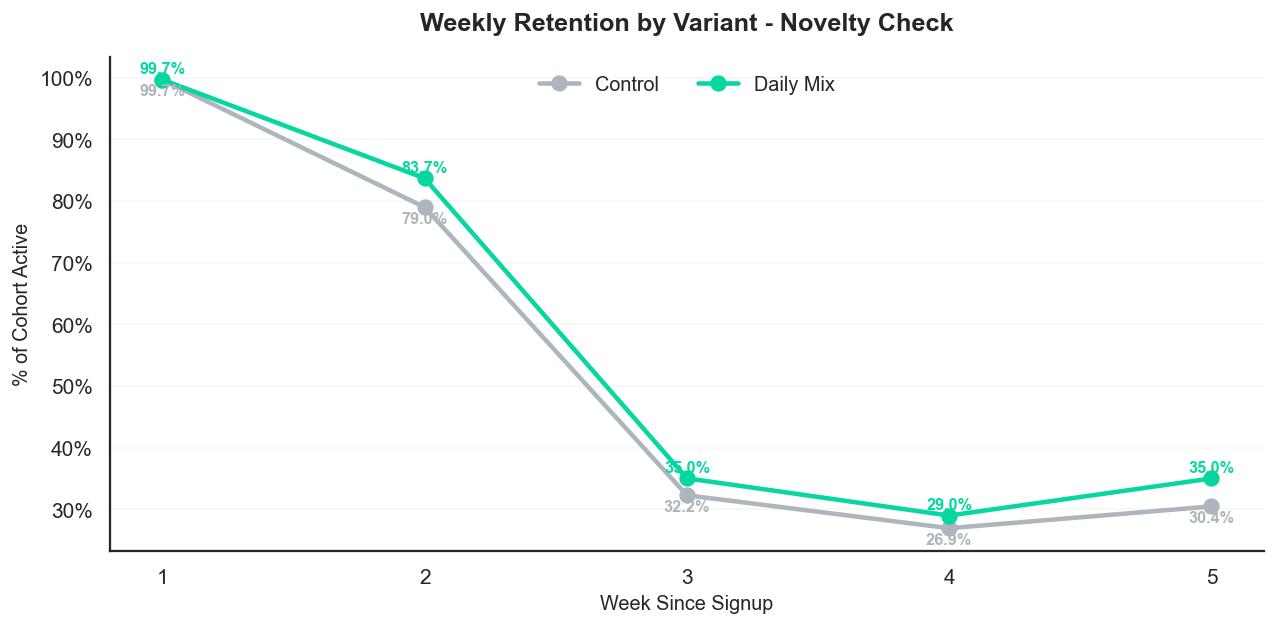

In [10]:
weekly_retention = con.execute("""
    WITH weekly_active AS (
        SELECT
            u.user_id,
            u.experiment_variant,
            FLOOR((CAST(e.event_time AS DATE) - CAST(u.signup_date AS DATE)) / 7) + 1 AS week_num
        FROM events e
        JOIN users u ON e.user_id = u.user_id
        WHERE e.event_type IN ('play', 'app_open', 'daily_mix_play')
          AND CAST(e.event_time AS DATE) - CAST(u.signup_date AS DATE) BETWEEN 0 AND 30
        GROUP BY u.user_id, u.experiment_variant, week_num
    ),
    cohort AS (
        SELECT experiment_variant, COUNT(DISTINCT user_id) AS total
        FROM users GROUP BY experiment_variant
    )
    SELECT
        wa.experiment_variant,
        wa.week_num,
        COUNT(DISTINCT wa.user_id) AS active,
        c.total AS cohort_size,
        ROUND(100.0 * COUNT(DISTINCT wa.user_id) / c.total, 2) AS retention_pct
    FROM weekly_active wa
    JOIN cohort c ON wa.experiment_variant = c.experiment_variant
    GROUP BY wa.experiment_variant, wa.week_num, c.total
    ORDER BY wa.week_num, wa.experiment_variant
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 5))

for variant, color, label, offset in [("control", GREY, "Control", -1.8), ("daily_mix", GREEN, "Daily Mix", 1.8)]:
    data = weekly_retention[weekly_retention["experiment_variant"] == variant].sort_values("week_num")
    ax.plot(data["week_num"], data["retention_pct"], marker="o", color=color,
            linewidth=2.5, markersize=8, label=label)

    for _, row in data.iterrows():
        ax.text(row["week_num"], row["retention_pct"] + offset,
                f'{row["retention_pct"]:.1f}%', ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

ax.set_title("Weekly Retention by Variant - Novelty Check", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Week Since Signup", fontsize=11)
ax.set_ylabel("% of Cohort Active", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(sorted(weekly_retention["week_num"].unique()))
ax.legend(fontsize=11, frameon=False, loc="upper center", ncol=2)
ax.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.show()

## Segment Analysis
Does the treatment effect hold across platforms and countries, or is it driven by a specific segment?

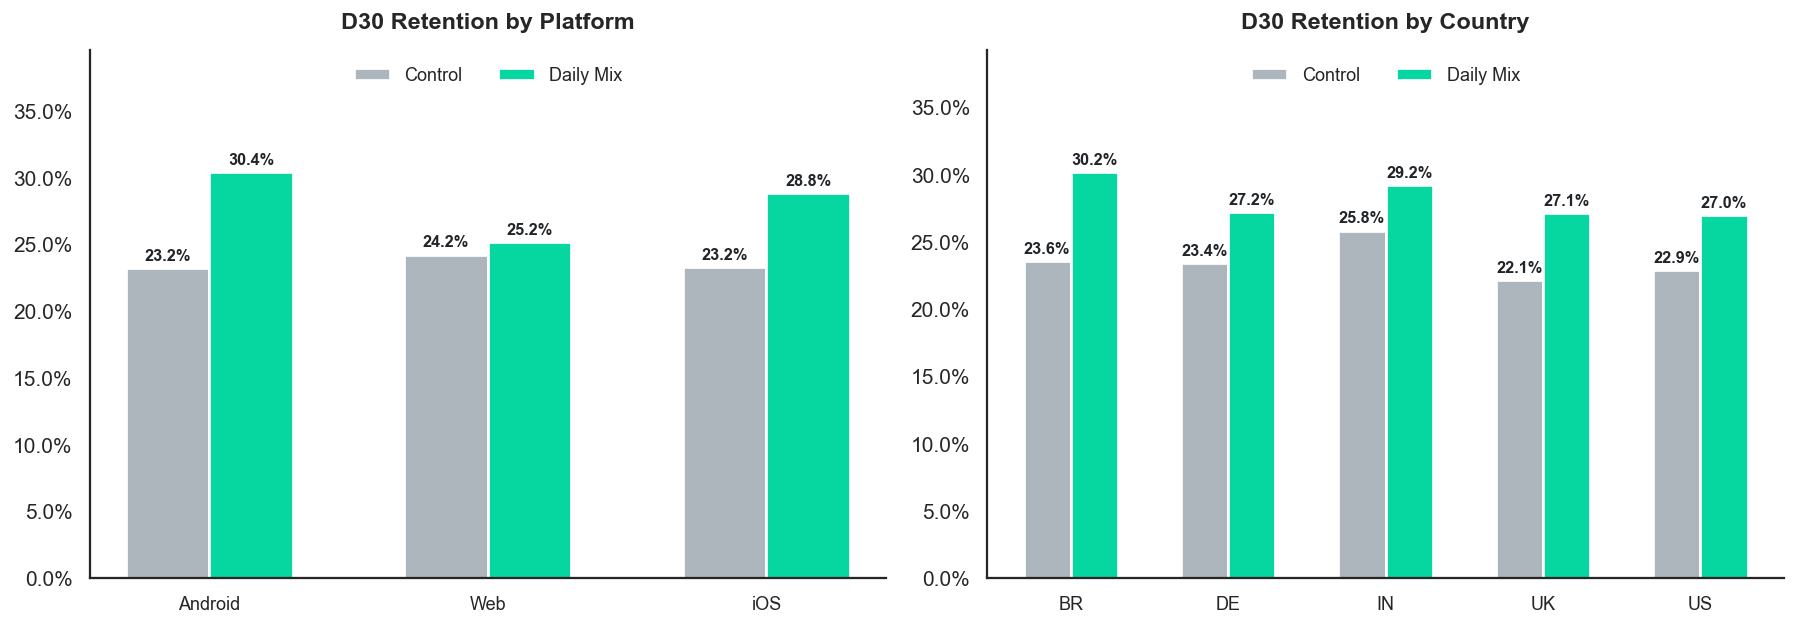

In [11]:
segments = con.execute("""
    WITH d30 AS (
        SELECT DISTINCT e.user_id
        FROM events e JOIN users u ON e.user_id = u.user_id
        WHERE CAST(e.event_time AS DATE) = CAST(u.signup_date AS DATE) + 30
          AND e.event_type IN ('play', 'app_open', 'daily_mix_play')
    )
    SELECT
        u.experiment_variant,
        u.platform,
        u.country,
        COUNT(DISTINCT u.user_id) AS cohort,
        COUNT(DISTINCT d30.user_id) AS retained,
        ROUND(100.0 * COUNT(DISTINCT d30.user_id) / COUNT(DISTINCT u.user_id), 2) AS d30_pct
    FROM users u
    LEFT JOIN d30 ON u.user_id = d30.user_id
    GROUP BY u.experiment_variant, u.platform, u.country
""").fetchdf()

# Platform view
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dim, title in zip(axes, ["platform", "country"], ["Platform", "Country"]):
    pivot = segments.groupby([dim, "experiment_variant"])["d30_pct"].mean().reset_index()
    cats = pivot[dim].unique()
    x = np.arange(len(cats))
    width = 0.3

    ctrl_vals = pivot[pivot["experiment_variant"] == "control"].set_index(dim).reindex(cats)["d30_pct"]
    treat_vals = pivot[pivot["experiment_variant"] == "daily_mix"].set_index(dim).reindex(cats)["d30_pct"]

    ax.bar(x - width/2, ctrl_vals, width, label="Control", color=GREY,
           edgecolor="white", linewidth=1.5)
    ax.bar(x + width/2, treat_vals, width, label="Daily Mix", color=GREEN,
           edgecolor="white", linewidth=1.5)

    max_val = max(ctrl_vals.max(), treat_vals.max())
    ax.set_ylim(0, max_val * 1.3)

    for i, (c, t) in enumerate(zip(ctrl_vals, treat_vals)):
        ax.text(i - width/2, c + max_val * 0.02, f"{c:.1f}%", ha="center",
                fontsize=9, fontweight="bold", color=DARK)
        ax.text(i + width/2, t + max_val * 0.02, f"{t:.1f}%", ha="center",
                fontsize=9, fontweight="bold", color=DARK)

    ax.set_xticks(x)
    ax.set_xticklabels(cats, fontsize=10)
    ax.set_title(f"D30 Retention by {title}", fontsize=13, fontweight="bold", pad=12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=10, frameon=False, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

## Sample Size & Statistical Power
Was the experiment adequately powered? We compute the minimum detectable effect (MDE) at 80% power and check whether our observed effect exceeds it.

In [12]:
from statsmodels.stats.proportion import power_proportions_2indep

baseline = ctrl_rate
n_per_arm = int((ctrl["cohort"] + treat["cohort"]) / 2)

# MDE at 80% power, alpha=0.05
for mde_pp in np.arange(0.5, 10.0, 0.1):
    target_rate = baseline + mde_pp / 100
    diff = mde_pp / 100
    result = power_proportions_2indep(diff, baseline, n_per_arm, alpha=0.05)
    if result.power >= 0.80:
        break

observed_effect = lift_pp

print(f"Sample size per arm: ~{n_per_arm:,}")
print(f"Baseline D30 retention: {baseline*100:.1f}%")
print(f"Minimum detectable effect (80% power, a=0.05): {mde_pp:.1f} pp")
print(f"Observed effect: {observed_effect:.1f} pp")
print(f"\n{'Adequately powered' if observed_effect >= mde_pp else 'Underpowered -- observed effect below MDE'}")

Sample size per arm: ~6,000
Baseline D30 retention: 23.3%
Minimum detectable effect (80% power, a=0.05): 2.2 pp
Observed effect: 5.3 pp

Adequately powered


## Summary & Hard Decision

### Results

| Metric | Control | Treatment | Delta | Status |
|--------|---------|-----------|-------|--------|
| D30 retention | 23.3% | 28.6% | +5.3 pp | Significant |
| D7 retention | 55.1% | 64.5% | +9.3 pp | Significant |
| Weekly listening min | 45.6 median | 52.4 median | +14.7% | Significant |
| Search usage | 12.04 searches/user | 11.62 searches/user | -3.5% | Within threshold |
| Artist diversity (per 100 plays) | 66.81 | 53.55 | **-19.8%** | **Exceeds threshold** |
| Cannibalization | -- | -- | +11.2% total min | Monitor |

### The Hard Decision

Despite strong retention uplift, the **drop in artist diversity per 100 plays crosses our acceptable threshold (>10%)**. This means Daily Mix users hear the same popular artists repeatedly — the playlist is over-optimised toward "safe" content. While total unique artists are comparable (treatment users simply listen more), the *rate* of discovery is significantly lower.

Combined with evidence of partial cannibalization of editorial playlists, this suggests Daily Mix — as initially designed — harms long-term exploration and ecosystem health.

**Recommendation: Do not ship the initial design.**

### Next Steps
1. **Iterate on diversity constraints** — tighter caps on same-artist repeats, stronger new-artist injection (raise discovery slot from 5% to 25%).
2. **Reduce tile prominence** — test a lower Home position to balance against editorial playlists.
3. **Re-run experiment** with updated design, same guardrails.
4. **Maintain 5% long-term holdout** — even after eventual rollout, keep a "never-exposed" group to track long-term retention and diversity impact.

### Why This Decision Matters
Shipping a feature that lifts short-term retention but degrades the content ecosystem is a classic product trap. The right call is to invest another cycle to find the design that preserves both. This is a judgment call — not every positive A/B test should ship.